# EuroSAT SAR ↔ Optical Hybrid Retrieval Training

Training-only notebook using the paired RGB + MS + SAR TFRecords created previously.

Outputs:

- trained optical and SAR encoders
- classification reports for both modalities
- history subplots
- retrieval metrics DataFrame for:
  - Optical → Optical
  - SAR → SAR
  - Optical → SAR
  - SAR → Optical
- Precision@K, Recall@K and F1@K for configurable K values
- random test retrieval samples for all retrieval tasks
- inference-ready artifacts
- Kaggle upload of the complete results directory


In [1]:
!pip install -q -U kagglehub scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 106.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.0/231.0 kB 14.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
sklearn-compat 0.1.5 requires scikit-learn<1.9,>=1.2, but you have scikit-learn 1.9.0 which is incompatible.


In [2]:
import os, json, random, time, shutil
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from kaggle_secrets import UserSecretsClient
from sklearn.metrics import classification_report, confusion_matrix
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

tf.keras.mixed_precision.set_global_policy("float32")
tf.config.optimizer.set_jit(False)
user_secrets = UserSecretsClient()

os.environ["KAGGLE_USERNAME"] = user_secrets.get_secret("KAGGLE_USERNAME")
os.environ["KAGGLE_KEY"] = user_secrets.get_secret("KAGGLE_KEY")
TFRECORD_HANDLE = f'{user_secrets.get_secret("KAGGLE_USERNAME")}/eurosat-rgb-ms-sar-paired-tfrecords'

OUT_DIR = Path("/kaggle/working/eurodata_sar_optical_hybrid_results")
MODEL_DIR = OUT_DIR / "models"
REPORT_DIR = OUT_DIR / "reports"
PLOT_DIR = OUT_DIR / "plots"
EMB_DIR = OUT_DIR / "embeddings"

for d in [OUT_DIR, MODEL_DIR, REPORT_DIR, PLOT_DIR, EMB_DIR]:
    d.mkdir(parents=True, exist_ok=True)

IMAGE_SIZE = 64
RGB_CHANNELS = 3
SAR_CHANNELS = 2
NUM_CLASSES = 10

BATCH_SIZE = 64
EPOCHS = 100

EMBED_DIM = 256

LR = 1e-4
WEIGHT_DECAY = 1e-5
MARGIN = 0.2
TEMPERATURE = 1.0

K_LIST = [1, 5, 10, 20, 50]

CLASS_NAMES = [
    "AnnualCrop",
    "Forest",
    "HerbaceousVegetation",
    "Highway",
    "Industrial",
    "Pasture",
    "PermanentCrop",
    "Residential",
    "River",
    "SeaLake",
]

print(tf.__version__)

2026-06-24 23:20:26.221946: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782343226.388760      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782343226.438309      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782343226.839677      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782343226.839714      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782343226.839716      23 computation_placer.cc:177] computation placer alr

2.19.0


## 1. Download and load paired TFRecords

In [3]:
TFRECORD_HANDLE

'glitchr/eurosat-rgb-ms-sar-paired-tfrecords'

In [4]:
TFREC_DIR = Path(kagglehub.dataset_download(TFRECORD_HANDLE))

roots = [TFREC_DIR] + [p.parent for p in TFREC_DIR.rglob("manifest.json")]
TFREC_DIR = next(r for r in roots if (r / "manifest.json").exists())

manifest = json.loads((TFREC_DIR / "manifest.json").read_text())

SAR_MEAN = np.asarray(manifest["sar_normalization"]["mean"], np.float32)
SAR_STD = np.asarray(manifest["sar_normalization"]["std"], np.float32)

SAR_MEAN_T = tf.constant(SAR_MEAN.reshape(1, 1, -1))
SAR_STD_T = tf.constant(SAR_STD.reshape(1, 1, -1))

train_df = pd.read_csv(TFREC_DIR / "train_metadata.csv")
validation_df = pd.read_csv(TFREC_DIR / "validation_metadata.csv")
test_df = pd.read_csv(TFREC_DIR / "test_metadata.csv")

FEATURE_SPEC = {
    "rgb_raw": tf.io.FixedLenFeature([], tf.string),
    "ms_raw": tf.io.FixedLenFeature([], tf.string),
    "sar_raw": tf.io.FixedLenFeature([], tf.string),
    "target": tf.io.FixedLenFeature([], tf.int64),
    "file_id": tf.io.FixedLenFeature([], tf.string),
    "label": tf.io.FixedLenFeature([], tf.string),
}

def shard_paths(split):
    names = manifest["splits"][split]["shards"]
    paths = []

    for name in names:
        p = TFREC_DIR / name

        if not p.exists() and name.endswith(".gz"):
            p = TFREC_DIR / name[:-3]

        if not p.exists() and name.endswith(".tfrecord"):
            p = TFREC_DIR / f"{name}.gz"

        if not p.exists():
            raise FileNotFoundError(name)

        paths.append(str(p))

    comp = "GZIP" if all(p.endswith(".gz") for p in paths) else ""
    return paths, comp

def decode_record(x):
    x = tf.io.parse_single_example(x, FEATURE_SPEC)

    rgb = tf.ensure_shape(
        tf.io.parse_tensor(x["rgb_raw"], tf.uint8),
        [IMAGE_SIZE, IMAGE_SIZE, RGB_CHANNELS],
    )

    sar = tf.ensure_shape(
        tf.io.parse_tensor(x["sar_raw"], tf.float16),
        [IMAGE_SIZE, IMAGE_SIZE, SAR_CHANNELS],
    )

    rgb = tf.cast(rgb, tf.float32) / 255.0

    sar = (
        tf.cast(sar, tf.float32) - SAR_MEAN_T
    ) / tf.maximum(SAR_STD_T, 1e-3)

    sar = tf.clip_by_value(sar, -5.0, 5.0)

    return {
        "rgb": rgb,
        "sar": sar,
        "file_id": x["file_id"],
        "label": x["label"],
    }, tf.cast(x["target"], tf.int32)

def augment(x, y):
    s = tf.random.uniform([2], maxval=2**31 - 1, dtype=tf.int32)
    s2 = s + tf.constant([17, 29])
    k = tf.random.stateless_uniform([], s + tf.constant([31, 43]), 0, 4, dtype=tf.int32)

    rgb = tf.image.stateless_random_flip_left_right(x["rgb"], s)
    sar = tf.image.stateless_random_flip_left_right(x["sar"], s)

    rgb = tf.image.stateless_random_flip_up_down(rgb, s2)
    sar = tf.image.stateless_random_flip_up_down(sar, s2)

    rgb = tf.image.rot90(rgb, k)
    sar = tf.image.rot90(sar, k)

    rgb = tf.clip_by_value(
        tf.image.stateless_random_contrast(
            tf.image.stateless_random_brightness(rgb, 0.05, s + 59),
            0.9,
            1.1,
            s + 71,
        ),
        0,
        1,
    )

    sar = tf.clip_by_value(
        sar * tf.random.stateless_uniform([1, 1, SAR_CHANNELS], s + 83, 0.97, 1.03),
        -5,
        5,
    )

    return {
        "rgb": rgb,
        "sar": sar,
        "file_id": x["file_id"],
        "label": x["label"],
    }, y

def make_ds(split, training=False, metadata=False):
    p, c = shard_paths(split)

    ds = tf.data.TFRecordDataset(
        p,
        compression_type=c,
        num_parallel_reads=tf.data.AUTOTUNE,
    ).map(
        decode_record,
        num_parallel_calls=tf.data.AUTOTUNE,
        deterministic=not training,
    )

    if training:
        ds = ds.shuffle(
            min(int(manifest["splits"][split]["examples"]), 8192),
            SEED,
            reshuffle_each_iteration=True,
        ).map(
            augment,
            num_parallel_calls=tf.data.AUTOTUNE,
            deterministic=False,
        )

    if not metadata:
        ds = ds.map(
            lambda x, y: ({"rgb": x["rgb"], "sar": x["sar"]}, y),
            num_parallel_calls=tf.data.AUTOTUNE,
        )

    return ds.batch(BATCH_SIZE, drop_remainder=training).prefetch(tf.data.AUTOTUNE)

train_ds = make_ds("train", True)
val_ds = make_ds("validation")
test_ds = make_ds("test")
test_meta_ds = make_ds("test", metadata=True)

sample_x, sample_y = next(iter(train_ds))

print(sample_x["rgb"].shape, sample_x["sar"].shape, sample_y.shape)

I0000 00:00:1782343240.249391      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


(64, 64, 64, 3) (64, 64, 64, 2) (64,)


## 2. Hybrid encoder: modified ResNet + Coordinate Attention + SE + attention pooling

In [5]:
L = tf.keras.layers

@tf.keras.utils.register_keras_serializable(package="EuroData")
class SE(L.Layer):
    def __init__(self, r=16, **k):
        super().__init__(**k)
        self.r = r

    def build(self, s):
        c = int(s[-1])
        self.a = L.Conv2D(max(c // self.r, 8), 1, activation="relu")
        self.b = L.Conv2D(c, 1, activation="sigmoid")

    def call(self, x):
        return x * self.b(self.a(tf.reduce_mean(x, [1, 2], keepdims=True)))

@tf.keras.utils.register_keras_serializable(package="EuroData")
class CoordAtt(L.Layer):
    def __init__(self, r=8, **k):
        super().__init__(**k)
        self.r = r

    def build(self, s):
        c = int(s[-1])
        q = max(c // self.r, 8)
        self.c = L.Conv2D(q, 1, use_bias=False)
        self.bn = L.BatchNormalization()
        self.h = L.Conv2D(c, 1, activation="sigmoid")
        self.w = L.Conv2D(c, 1, activation="sigmoid")

    def call(self, x, training=None):
        sh = tf.shape(x)
        h, w = sh[1], sh[2]
        a = tf.reduce_mean(x, 2, keepdims=True)
        b = tf.transpose(tf.reduce_mean(x, 1, keepdims=True), [0, 2, 1, 3])
        z = tf.nn.silu(self.bn(self.c(tf.concat([a, b], 1)), training=training))
        ah = self.h(z[:, :h])
        aw = self.w(tf.transpose(z[:, h:h + w], [0, 2, 1, 3]))
        return x * ah * aw

@tf.keras.utils.register_keras_serializable(package="EuroData")
class BalancedAtt(L.Layer):
    def build(self, s):
        self.ca = CoordAtt()
        self.se = SE()
        self.alpha = self.add_weight(
            shape=(),
            initializer="zeros",
            trainable=True,
            name="fusion_logit",
        )

    def call(self, x, training=None):
        w = tf.sigmoid(self.alpha)
        return w * self.ca(x, training=training) + (1 - w) * self.se(x)

@tf.keras.utils.register_keras_serializable(package="EuroData")
class AttPool(L.Layer):
    def __init__(self, d=256, h=8, **k):
        super().__init__(**k)
        self.d = d
        self.h = h

    def build(self, s):
        self.p = L.Dense(self.d)
        self.a = L.MultiHeadAttention(self.h, self.d // self.h, output_shape=self.d)
        self.o = L.Dense(self.d)
        self.q = self.add_weight(
            shape=(1, 1, self.d),
            initializer="glorot_uniform",
            trainable=True,
            name="query",
        )

    def call(self, x, training=None):
        sh = tf.shape(x)
        t = self.p(tf.reshape(tf.cast(x, tf.float32), [sh[0], sh[1] * sh[2], sh[3]]))
        q = tf.tile(self.q, [sh[0], 1, 1])
        return self.o(tf.squeeze(self.a(q, t, t, training=training), 1))

def cbr(x, f, k=3, s=1, n="c"):
    x = L.Conv2D(
        f, k, s,
        padding="same",
        use_bias=False,
        kernel_initializer="he_normal",
        name=n + "_conv",
    )(x)
    x = L.BatchNormalization(name=n + "_bn")(x)
    return L.ReLU(name=n + "_relu")(x)

def block(x, f, s=1, n="b"):
    sc = x

    y = cbr(x, f, 1, n=n + "1")
    y = cbr(y, f, 3, n=n + "2")
    y = L.Conv2D(f * 4, 1, padding="same", use_bias=False, name=n + "3_conv")(y)
    y = L.BatchNormalization(name=n + "3_bn")(y)
    y = BalancedAtt(name=n + "_att")(y)

    if s > 1:
        y = L.AveragePooling2D(s, s, padding="same")(y)
        sc = L.AveragePooling2D(s, s, padding="same")(sc)

    if x.shape[-1] != f * 4 or s > 1:
        sc = L.Conv2D(f * 4, 1, padding="same", use_bias=False)(sc)
        sc = L.BatchNormalization()(sc)

    return L.ReLU()(L.Add()([sc, y]))

def build_encoder(shape, name):
    i = tf.keras.Input(shape)

    x = cbr(i, 64, 3, 2, name + "_stem1")
    x = cbr(x, 64, 3, 1, name + "_stem2")
    x = cbr(x, 64, 3, 1, name + "_stem3")
    x = L.AveragePooling2D(2, 2, padding="same")(x)

    for si, (f, bn) in enumerate(zip([64, 128, 256, 512], [3, 4, 6, 3]), 1):
        for bi in range(1, bn + 1):
            x = block(
                x,
                f,
                2 if si > 1 and bi == 1 else 1,
                f"{name}_s{si}b{bi}",
            )

    x = AttPool(EMBED_DIM, 8, name=name + "_pool")(x)
    x = L.Dense(EMBED_DIM, use_bias=False, name=name + "_emb_dense")(x)
    x = L.BatchNormalization(name=name + "_emb_bn")(x)

    e = L.UnitNormalization(
        axis=-1,
        name=name + "_embedding",
    )(x)

    return tf.keras.Model(i, e, name=name)

optical_encoder = build_encoder(
    (IMAGE_SIZE, IMAGE_SIZE, RGB_CHANNELS),
    "optical_encoder",
)

sar_encoder = build_encoder(
    (IMAGE_SIZE, IMAGE_SIZE, SAR_CHANNELS),
    "sar_encoder",
)

print(optical_encoder.output_shape, sar_encoder.output_shape)

(None, 256) (None, 256)


## 3. Hybrid cross-modal training model

In [6]:
def triplet_loss(y, e, m=MARGIN):
    y = tf.reshape(tf.cast(y, tf.int32), [-1])
    d = tf.maximum(tf.expand_dims(tf.reduce_sum(e * e, 1), 1) - 2 * tf.matmul(e, e, transpose_b=True) + tf.expand_dims(tf.reduce_sum(e * e, 1), 0), 0.0)
    eq = tf.equal(y[:, None], y[None, :])
    pos = tf.logical_and(eq, tf.logical_not(tf.eye(tf.shape(y)[0], dtype=tf.bool)))
    neg = tf.logical_not(eq)
    hp = tf.reduce_max(tf.where(pos, d, tf.zeros_like(d)), 1)
    hn = tf.reduce_min(tf.where(neg, d, tf.fill(tf.shape(d), 1e9)), 1)
    valid = tf.logical_and(tf.reduce_any(pos, 1), tf.reduce_any(neg, 1))
    z = tf.boolean_mask(tf.maximum(hp - hn + m, 0), valid)
    return tf.cond(tf.size(z) > 0, lambda: tf.reduce_mean(z), lambda: tf.constant(0.0))

def align_loss(a, b, y, t=TEMPERATURE):
    y = tf.reshape(tf.cast(y, tf.int32), [-1])
    s = tf.matmul(tf.math.l2_normalize(a, 1), tf.math.l2_normalize(b, 1), transpose_b=True) / t
    p = tf.cast(tf.equal(y[:, None], y[None, :]), tf.float32)
    q = p / tf.maximum(tf.reduce_sum(p, 1, keepdims=True), 1.0)
    return .5 * (
        tf.reduce_mean(tf.nn.softmax_cross_entropy_with_logits(q, s))
        + tf.reduce_mean(tf.nn.softmax_cross_entropy_with_logits(tf.transpose(q), tf.transpose(s)))
    )

class HybridModel(tf.keras.Model):
    def __init__(self):
        super().__init__()
        self.oe = optical_encoder
        self.se = sar_encoder
        self.oc = L.Dense(NUM_CLASSES, name="optical_classifier")
        self.sc = L.Dense(NUM_CLASSES, name="sar_classifier")
        self.mt = [tf.keras.metrics.Mean(name=n) for n in ["loss", "triplet_loss", "classification_loss", "alignment_loss"]]
        self.oa = tf.keras.metrics.SparseCategoricalAccuracy(name="optical_accuracy")
        self.sa = tf.keras.metrics.SparseCategoricalAccuracy(name="sar_accuracy")

    @property
    def metrics(self):
        return self.mt + [self.oa, self.sa]

    def call(self, x, training=False):
        oe = self.oe(x["rgb"], training=training)
        se = self.se(x["sar"], training=training)
        return {
            "optical_embedding": oe,
            "sar_embedding": se,
            "optical_logits": self.oc(oe),
            "sar_logits": self.sc(se),
        }

    def losses_all(self, x, y, training):
        o = self(x, training=training)

        tr = .5 * (
            triplet_loss(y, o["optical_embedding"])
            + triplet_loss(y, o["sar_embedding"])
        )

        ce = .5 * (
            tf.reduce_mean(tf.keras.losses.sparse_categorical_crossentropy(y, o["optical_logits"], from_logits=True))
            + tf.reduce_mean(tf.keras.losses.sparse_categorical_crossentropy(y, o["sar_logits"], from_logits=True))
        )

        al = align_loss(o["optical_embedding"], o["sar_embedding"], y)

        total = tr + ce + al + (tf.add_n(self.losses) if self.losses else 0.0)

        return total, tr, ce, al, o

    def step(self, data, train):
        x, y = data

        if train:
            with tf.GradientTape() as tape:
                vals = self.losses_all(x, y, True)

            g = tape.gradient(vals[0], self.trainable_variables)
            self.optimizer.apply_gradients(
                [(a, b) for a, b in zip(g, self.trainable_variables) if a is not None]
            )
        else:
            vals = self.losses_all(x, y, False)

        for m, v in zip(self.mt, vals[:4]):
            m.update_state(v)

        self.oa.update_state(y, vals[4]["optical_logits"])
        self.sa.update_state(y, vals[4]["sar_logits"])

        return {m.name: m.result() for m in self.metrics}

    def train_step(self, data):
        return self.step(data, True)

    def test_step(self, data):
        return self.step(data, False)

model = HybridModel()
_ = model({"rgb": sample_x["rgb"][:2], "sar": sample_x["sar"][:2]})

model.compile(
    tf.keras.optimizers.AdamW(
        LR,
        weight_decay=WEIGHT_DECAY,
        global_clipnorm=1.0,
    ),
    jit_compile=False,
)

CKPT = MODEL_DIR / "best.weights.h5"

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        CKPT,
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True,
        verbose=1,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.CSVLogger(REPORT_DIR / "history.csv"),
    tf.keras.callbacks.TerminateOnNaN(),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1,
)

model.load_weights(CKPT)

optical_encoder.save(MODEL_DIR / "optical_encoder.keras")
sar_encoder.save(MODEL_DIR / "sar_encoder.keras")

I0000 00:00:1782343256.385438      23 cuda_dnn.cc:529] Loaded cuDNN version 91002


Epoch 1/100
    295/Unknown 284s 453ms/step - alignment_loss: 3.9659 - classification_loss: 2.0244 - loss: 6.9893 - optical_accuracy: 0.5490 - sar_accuracy: 0.4745 - triplet_loss: 0.9990

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 1: val_loss improved from None to 6.63207, saving model to /kaggle/working/eurodata_sar_optical_hybrid_results/models/best.weights.h5

Epoch 1: finished saving model to /kaggle/working/eurodata_sar_optical_hybrid_results/models/best.weights.h5
295/295 ━━━━━━━━━━━━━━━━━━━━ 302s 517ms/step - alignment_loss: 3.8825 - classification_loss: 1.8883 - loss: 6.6402 - optical_accuracy: 0.6341 - sar_accuracy: 0.5647 - triplet_loss: 0.8693 - val_alignment_loss: 4.0232 - val_classification_loss: 2.0034 - val_loss: 6.6321 - val_optical_accuracy: 0.2035 - val_sar_accuracy: 0.4659 - val_triplet_loss: 0.6055
Epoch 2/100
295/295 ━━━━━━━━━━━━━━━━━━━━ 0s 449ms/step - alignment_loss: 3.7716 - classification_loss: 1.6333 - loss: 6.1204 - optical_accuracy: 0.7162 - sar_accuracy: 0.6411 - triplet_loss: 0.7155
Epoch 2: val_loss improved from 6.63207 to 5.81170, saving model to /kaggle/working/eurodata_sar_optical_hybrid_results/models/best.weights.h5

Epoch 2: finished saving model to /kaggle/working/eu

## 4. History subplots

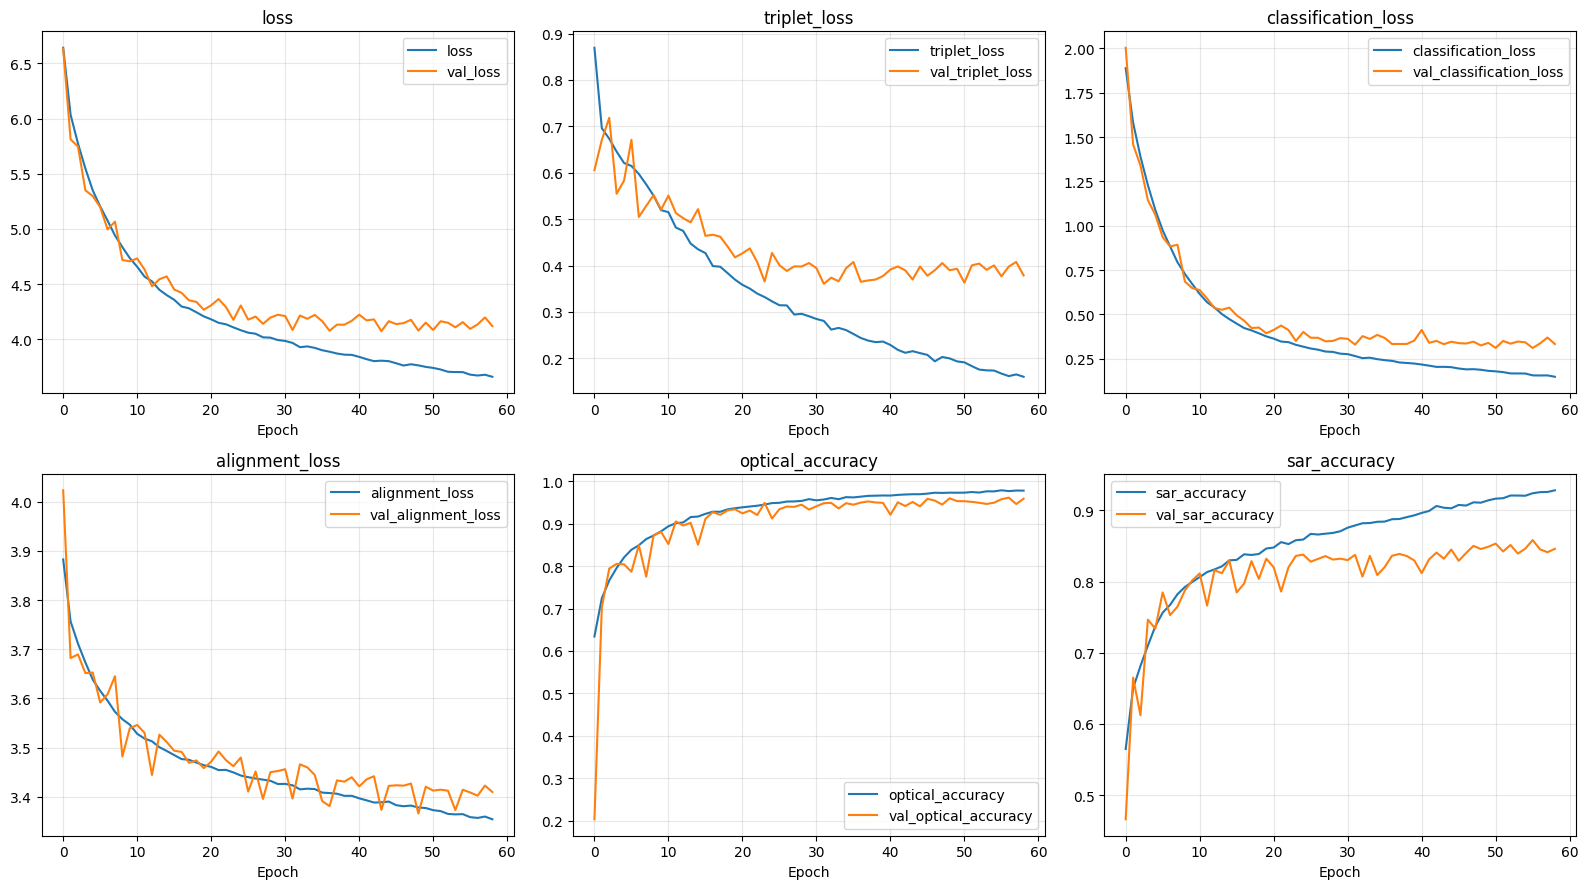

In [7]:
h = pd.DataFrame(history.history)

metrics = [
    "loss",
    "triplet_loss",
    "classification_loss",
    "alignment_loss",
    "optical_accuracy",
    "sar_accuracy",
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()

for ax, m in zip(axes, metrics):
    if m in h:
        ax.plot(h[m], label=m)

    if "val_" + m in h:
        ax.plot(h["val_" + m], label="val_" + m)

    ax.set_title(m)
    ax.set_xlabel("Epoch")
    ax.grid(True, alpha=.3)
    ax.legend()

plt.tight_layout()
plt.savefig(PLOT_DIR / "training_history_subplots.png", dpi=180)
plt.show()

## 5. Classification reports for optical and SAR

In [8]:
def predict_test(ds):
    yt, op, sp, oe, se, ids, names = [], [], [], [], [], [], []

    for x, y in tqdm(ds):
        o = model({"rgb": x["rgb"], "sar": x["sar"]}, training=False)

        yt.append(y.numpy())
        op.append(np.argmax(o["optical_logits"].numpy(), 1))
        sp.append(np.argmax(o["sar_logits"].numpy(), 1))
        oe.append(o["optical_embedding"].numpy())
        se.append(o["sar_embedding"].numpy())
        ids.append(x["file_id"].numpy())
        names.extend(v.decode() for v in x["label"].numpy())

    return {
        k: np.concatenate(v) if isinstance(v, list) and v and isinstance(v[0], np.ndarray) else np.asarray(v)
        for k, v in {
            "y": yt,
            "optical_pred": op,
            "sar_pred": sp,
            "optical_emb": oe,
            "sar_emb": se,
            "file_id": ids,
            "label": names,
        }.items()
    }

pred = predict_test(test_meta_ds)

optical_report = pd.DataFrame(
    classification_report(
        pred["y"],
        pred["optical_pred"],
        target_names=CLASS_NAMES,
        output_dict=True,
        zero_division=0,
    )
).T.reset_index(names="class")

sar_report = pd.DataFrame(
    classification_report(
        pred["y"],
        pred["sar_pred"],
        target_names=CLASS_NAMES,
        output_dict=True,
        zero_division=0,
    )
).T.reset_index(names="class")

optical_report["modality"] = "Optical"
sar_report["modality"] = "SAR"

classification_report_df = pd.concat(
    [optical_report, sar_report],
    ignore_index=True,
)

classification_report_df.to_csv(
    REPORT_DIR / "classification_reports_optical_sar.csv",
    index=False,
)

display(classification_report_df)

0it [00:00, ?it/s]

,class,precision,recall,f1-score,support,modality
0,AnnualCrop,0.954649,0.935556,0.945006,450.000000,Optical
1,Forest,0.971861,0.997778,0.984649,450.000000,Optical
2,HerbaceousVegetation,0.927765,0.913333,0.920493,450.000000,Optical
3,Highway,0.991549,0.938667,0.964384,375.000000,Optical
4,Industrial,0.980556,0.941333,0.960544,375.000000,Optical
5,Pasture,0.914826,0.966667,0.940032,300.000000,Optical
6,PermanentCrop,0.909836,0.888000,0.898785,375.000000,Optical
7,Residential,0.959402,0.997778,0.978214,450.000000,Optical
8,River,0.941026,0.978667,0.959477,375.000000,Optical
9,SeaLake,0.991071,0.986667,0.988864,450.000000,Optical


## 6. Retrieval metrics for all same-modal and cross-modal tasks

In [9]:
def retrieval_metrics(q, g, ql, gl, direction, k_list=K_LIST, same_set=False):
    q = q / np.maximum(np.linalg.norm(q, axis=1, keepdims=True), 1e-8)
    g = g / np.maximum(np.linalg.norm(g, axis=1, keepdims=True), 1e-8)

    s = q @ g.T

    if same_set:
        np.fill_diagonal(s, -np.inf)

    r = np.argsort(-s, axis=1)
    rows = []

    for k in k_list:
        ps, rs, fs = [], [], []

        for i in range(len(q)):
            hit = gl[r[i, :k]] == ql[i]
            c = hit.sum()
            total = (gl == ql[i]).sum() - (1 if same_set else 0)

            p = c / k
            rec = c / max(total, 1)
            f = 2 * p * rec / max(p + rec, 1e-12)

            ps.append(p)
            rs.append(rec)
            fs.append(f)

        rows.append({
            "direction": direction,
            "k": k,
            "precision": np.mean(ps),
            "recall": np.mean(rs),
            "f1": np.mean(fs),
        })

    return pd.DataFrame(rows), s, r

tasks = {
    "Optical_to_Optical": (pred["optical_emb"], pred["optical_emb"], True),
    "SAR_to_SAR": (pred["sar_emb"], pred["sar_emb"], True),
    "Optical_to_SAR": (pred["optical_emb"], pred["sar_emb"], False),
    "SAR_to_Optical": (pred["sar_emb"], pred["optical_emb"], False),
}

metric_frames = []
retrieval_cache = {}

for name, (q, g, same) in tasks.items():
    df, sim, rank = retrieval_metrics(
        q,
        g,
        pred["label"],
        pred["label"],
        name,
        K_LIST,
        same,
    )

    metric_frames.append(df)
    retrieval_cache[name] = (sim, rank)

retrieval_metrics_df = pd.concat(metric_frames, ignore_index=True)

retrieval_metrics_df.to_csv(
    REPORT_DIR / "retrieval_metrics_at_k.csv",
    index=False,
)

display(retrieval_metrics_df)

display(
    retrieval_metrics_df.pivot(
        index="direction",
        columns="k",
        values=["precision", "recall", "f1"],
    )
)

,direction,k,precision,recall,f1
0,Optical_to_Optical,1,0.949877,0.002349,0.004687
1,Optical_to_Optical,5,0.951556,0.011763,0.023234
2,Optical_to_Optical,10,0.951481,0.023528,0.045902
3,Optical_to_Optical,20,0.951679,0.047067,0.089629
4,Optical_to_Optical,50,0.951990,0.117691,0.209138
5,SAR_to_SAR,1,0.811111,0.001995,0.003980
6,SAR_to_SAR,5,0.804296,0.009891,0.019537
7,SAR_to_SAR,10,0.804321,0.019773,0.038583
8,SAR_to_SAR,20,0.803765,0.039498,0.075243
9,SAR_to_SAR,50,0.802430,0.098511,0.175209


precision                                          \
k                         1         5         10        20        50   
direction                                                              
Optical_to_Optical  0.949877  0.951556  0.951481  0.951679  0.951990   
Optical_to_SAR      0.926173  0.930222  0.926765  0.926086  0.919472   
SAR_to_Optical      0.796296  0.805284  0.805531  0.807136  0.809378   
SAR_to_SAR          0.811111  0.804296  0.804321  0.803765  0.802430   

                      recall                                          \
k                         1         5         10        20        50   
direction                                                              
Optical_to_Optical  0.002349  0.011763  0.023528  0.047067  0.117691   
Optical_to_SAR      0.002283  0.011460  0.022830  0.045643  0.113305   
SAR_to_Optical      0.001934  0.009771  0.019549  0.039210  0.098360   
SAR_to_SAR          0.001995  0.009891  0.019773  0.039498  0.098511   

                          f1                                          
k                         1         5         10        20        50  
direction                                                             
Optical_to_Optical  0.004687  0.023234  0.045902  0.089629  0.209138  
Optical_to_SAR      0.004554  0.022637  0.044545  0.086934  0.201422  
SAR_to_Optical      0.003858  0.019304  0.038160  0.074740  0.175157  
SAR_to_SAR          0.003980  0.019537  0.038583  0.075243  0.175209

## 7. Random sample retrieval plots for all tasks

In [10]:
def stretch(x):
    finite = x[np.isfinite(x)]

    if finite.size == 0:
        return np.zeros_like(x, dtype=np.float32)

    low, high = np.percentile(finite, [2, 98])

    return np.clip((np.nan_to_num(x, nan=low) - low) / max(high - low, 1e-8), 0, 1)


def sar_gray(x):
    vv = stretch(x[..., 0])
    vh = stretch(x[..., 1])
    return 0.5 * (vv + vh)


def get_test_images(indices):
    store = {}
    needed = {int(index) for index in indices}
    offset = 0

    for inputs, targets in test_meta_ds:
        batch_size = len(targets)

        for batch_index in range(batch_size):
            sample_index = offset + batch_index

            if sample_index in needed:
                store[sample_index] = {
                    "rgb": inputs["rgb"][batch_index].numpy(),
                    "sar": inputs["sar"][batch_index].numpy(),
                    "label": inputs["label"][batch_index].numpy().decode(),
                }

        offset += batch_size

        if len(store) == len(needed):
            break

    missing = needed.difference(store)

    if missing:
        raise ValueError(f"Unable to load test images for indices: {sorted(missing)}")

    return store

In [11]:
TASK_INFO = {
    "Optical_to_Optical": {
        "title": "Optical → Optical Retrieval",
        "query_mode": "rgb",
        "gallery_mode": "rgb",
        "query_name": "Optical",
        "gallery_name": "Optical",
    },
    "SAR_to_SAR": {
        "title": "SAR → SAR Retrieval",
        "query_mode": "sar",
        "gallery_mode": "sar",
        "query_name": "SAR",
        "gallery_name": "SAR",
    },
    "Optical_to_SAR": {
        "title": "Optical → SAR Cross-Modal Retrieval",
        "query_mode": "rgb",
        "gallery_mode": "sar",
        "query_name": "Optical",
        "gallery_name": "SAR",
    },
    "SAR_to_Optical": {
        "title": "SAR → Optical Cross-Modal Retrieval",
        "query_mode": "sar",
        "gallery_mode": "rgb",
        "query_name": "SAR",
        "gallery_name": "Optical",
    },
}
def display_image(axis, image_data, mode):
    if mode == "sar": axis.imshow(sar_gray(image_data["sar"]), cmap="gray", vmin=0, vmax=1)
    else: axis.imshow(image_data["rgb"])
    axis.set_xticks([])
    axis.set_yticks([])
def set_border(axis, color, linewidth=4):
    axis.set_frame_on(True)
    for spine in axis.spines.values():
        spine.set_visible(True)
        spine.set_color(color)
        spine.set_linewidth(linewidth)

In [12]:
def plot_random_task(direction, top_k=10, query_index=None):
    if direction not in TASK_INFO:
        raise ValueError(f"Unsupported direction: {direction}")

    task = TASK_INFO[direction]
    similarity_matrix, ranked_indices = retrieval_cache[direction]

    if query_index is None:
        query_index = np.random.randint(len(pred["y"]))

    retrieved_indices = ranked_indices[query_index, :top_k]
    images = get_test_images([query_index, *retrieved_indices.tolist()])

    query = images[query_index]

    columns = 5
    result_rows = 2
    total_rows = 3

    if top_k > columns * result_rows:
        raise ValueError(f"top_k must be at most {columns * result_rows} for the three-row layout.")

    figure, axes = plt.subplots(total_rows, columns, figsize=(15, 10))

    for axis in axes.flat:
        axis.axis("off")

    figure.suptitle(task["title"], fontsize=18, fontweight="bold", y=0.98)

    query_axis = axes[0, columns // 2]

    display_image(query_axis, query, task["query_mode"])

    query_axis.axis("on")
    query_axis.set_xticks([])
    query_axis.set_yticks([])

    set_border(query_axis, color="blue", linewidth=5)

    query_axis.set_title(
        f"Query: {task['query_name']}\nClass: {query['label']}",
        fontsize=12,
        fontweight="bold",
        color="blue",
    )

    result_rows_data = []

    for rank_position, gallery_index in enumerate(retrieved_indices, start=1):
        plot_row = (rank_position - 1) // columns + 1
        plot_column = (rank_position - 1) % columns

        axis = axes[plot_row, plot_column]

        gallery_index = int(gallery_index)
        gallery = images[gallery_index]

        display_image(axis, gallery, task["gallery_mode"])

        axis.axis("on")
        axis.set_xticks([])
        axis.set_yticks([])

        relevant = int(gallery["label"] == query["label"])
        border_color = "green" if relevant else "red"
        result_status = "Correct" if relevant else "Wrong"

        set_border(axis, color=border_color, linewidth=4)

        similarity = float(similarity_matrix[query_index, gallery_index])

        axis.set_title(
            f"Rank {rank_position}: {task['gallery_name']}\n{gallery['label']} | {result_status}\nScore: {similarity:.3f}",
            fontsize=9,
            color=border_color,
            fontweight="bold",
        )

        result_rows_data.append({
            "direction": direction,
            "task": task["title"],
            "query_index": query_index,
            "query_modality": task["query_name"],
            "gallery_modality": task["gallery_name"],
            "rank": rank_position,
            "gallery_index": gallery_index,
            "query_label": query["label"],
            "gallery_label": gallery["label"],
            "score": similarity,
            "relevant": relevant,
            "result": result_status,
        })

    figure.text(
        0.5,
        0.02,
        "Blue border: Query     Green border: Correct match     Red border: Wrong match",
        ha="center",
        fontsize=11,
        fontweight="bold",
    )

    plt.tight_layout(rect=[0, 0.05, 1, 0.95])

    save_path = PLOT_DIR / f"{direction}_random_query_{query_index}.png"

    plt.savefig(save_path, dpi=180, bbox_inches="tight")
    plt.show()

    return pd.DataFrame(result_rows_data)

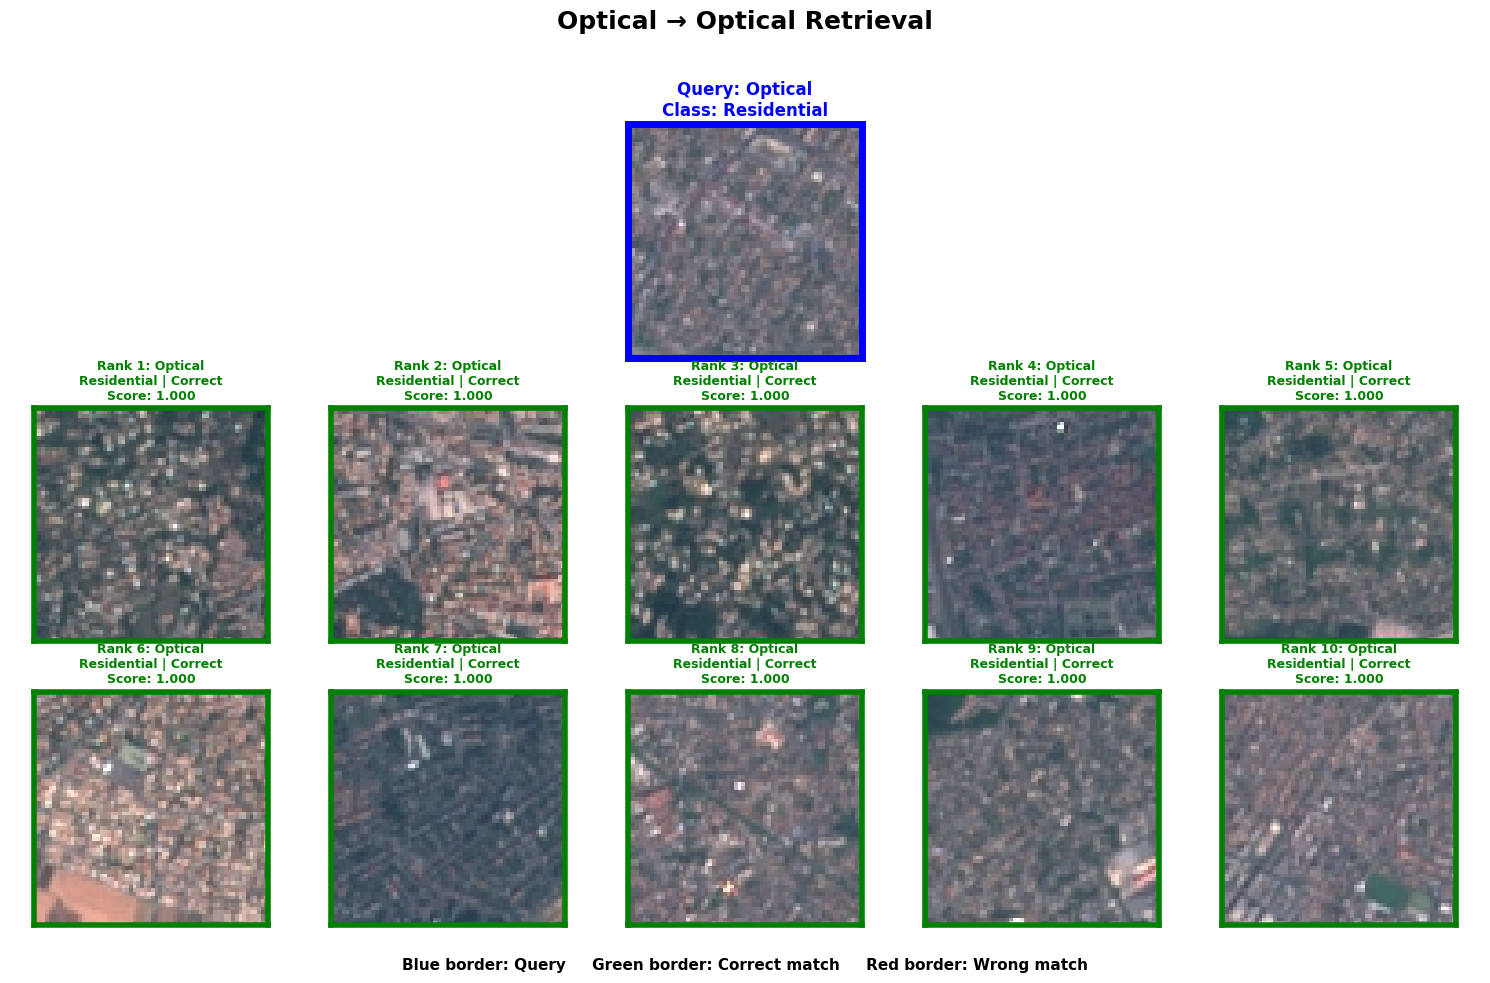

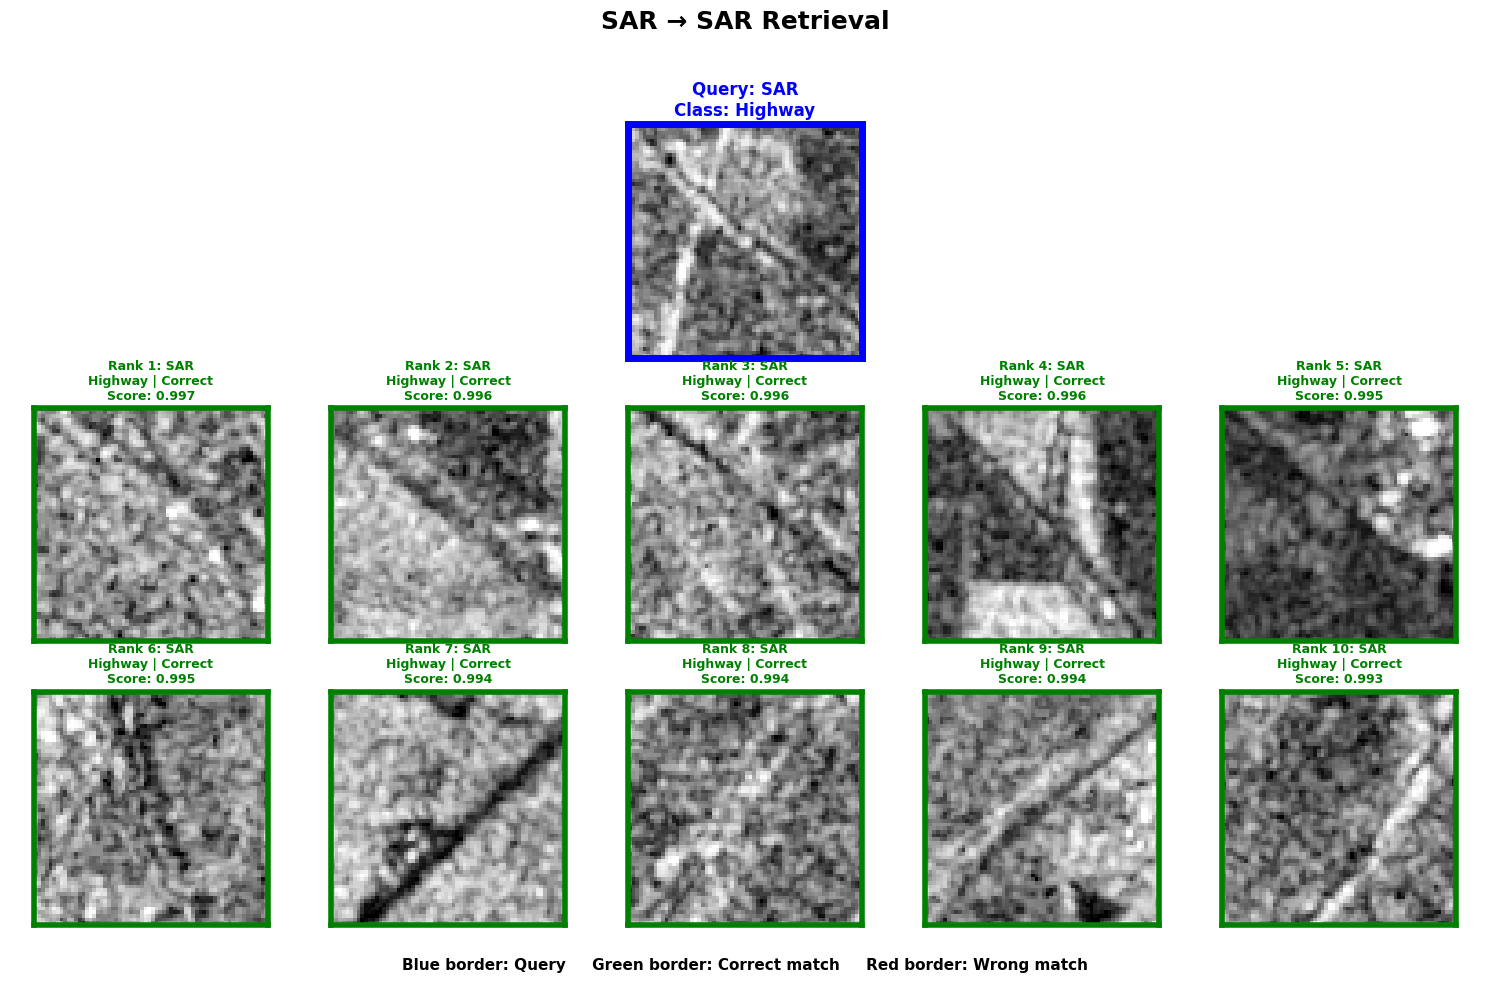

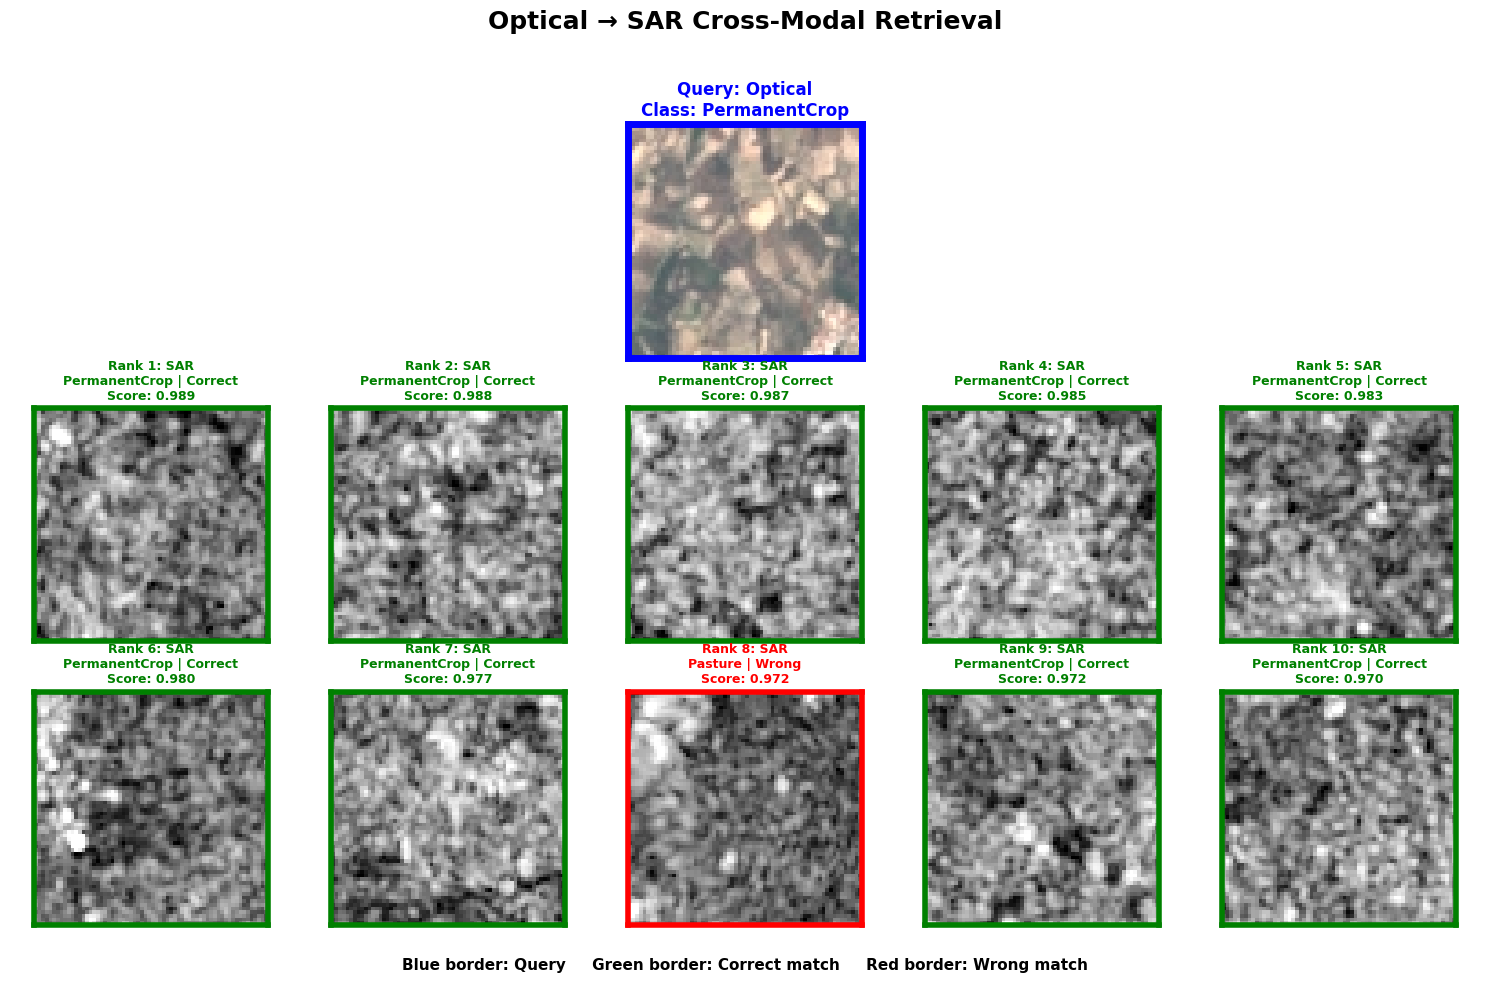

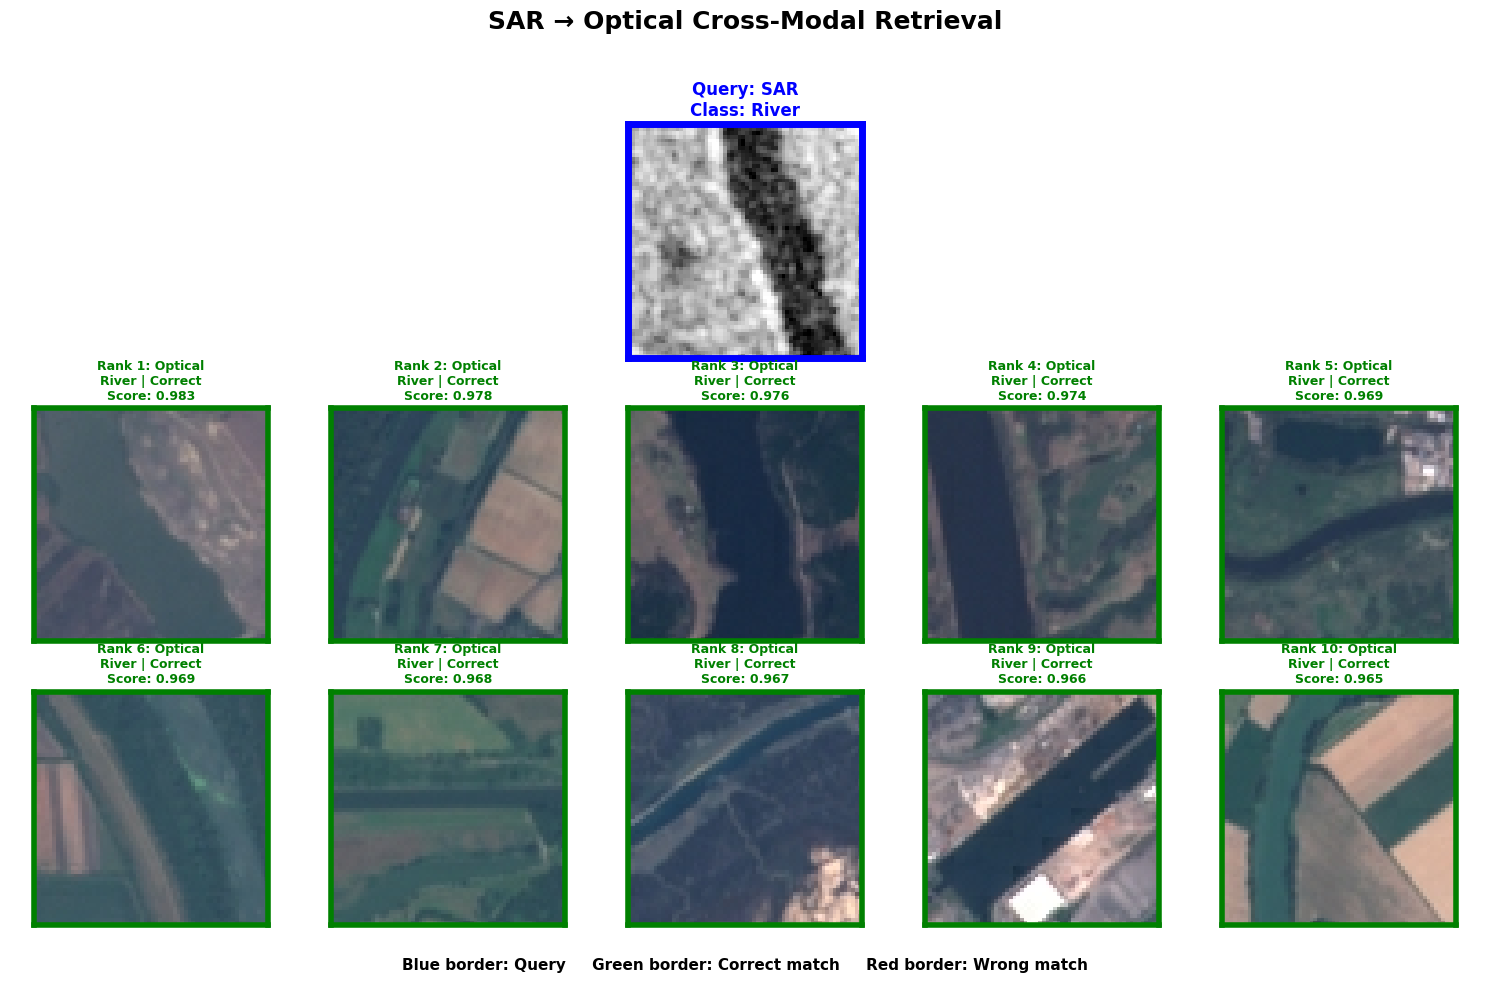

,direction,task,query_index,query_modality,gallery_modality,rank,gallery_index,query_label,gallery_label,score,relevant,result
0,Optical_to_Optical,Optical → Optical Retrieval,3174,Optical,Optical,1,3203,Residential,Residential,0.999941,1,Correct
1,Optical_to_Optical,Optical → Optical Retrieval,3174,Optical,Optical,2,3630,Residential,Residential,0.999935,1,Correct
2,Optical_to_Optical,Optical → Optical Retrieval,3174,Optical,Optical,3,318,Residential,Residential,0.999927,1,Correct
3,Optical_to_Optical,Optical → Optical Retrieval,3174,Optical,Optical,4,2896,Residential,Residential,0.999921,1,Correct
4,Optical_to_Optical,Optical → Optical Retrieval,3174,Optical,Optical,5,3984,Residential,Residential,0.999892,1,Correct
5,Optical_to_Optical,Optical → Optical Retrieval,3174,Optical,Optical,6,3980,Residential,Residential,0.999887,1,Correct
6,Optical_to_Optical,Optical → Optical Retrieval,3174,Optical,Optical,7,1015,Residential,Residential,0.999884,1,Correct
7,Optical_to_Optical,Optical → Optical Retrieval,3174,Optical,Optical,8,2175,Residential,Residential,0.999878,1,Correct
8,Optical_to_Optical,Optical → Optical Retrieval,3174,Optical,Optical,9,563,Residential,Residential,0.999878,1,Correct
9,Optical_to_Optical,Optical → Optical Retrieval,3174,Optical,Optical,10,2661,Residential,Residential,0.999876,1,Correct


In [13]:
sample_frames = []

for direction in [
    "Optical_to_Optical",
    "SAR_to_SAR",
    "Optical_to_SAR",
    "SAR_to_Optical",
]:
    sample_frames.append(
        plot_random_task(
            direction=direction,
            top_k=10,
        )
    )

sample_results = pd.concat(
    sample_frames,
    ignore_index=True,
)

sample_results.to_csv(
    REPORT_DIR / "random_retrieval_samples.csv",
    index=False,
)

display(sample_results)

## 8. Save inference-ready artifacts

In [14]:
np.save(EMB_DIR / "test_optical_embeddings.npy", pred["optical_emb"])
np.save(EMB_DIR / "test_sar_embeddings.npy", pred["sar_emb"])
np.save(EMB_DIR / "test_targets.npy", pred["y"])
np.save(EMB_DIR / "test_file_ids.npy", pred["file_id"])

test_df.to_csv(REPORT_DIR / "test_metadata.csv", index=False)

config = {
    "image_size": IMAGE_SIZE,
    "rgb_channels": RGB_CHANNELS,
    "sar_channels": SAR_CHANNELS,
    "sar_band_order": ["VV", "VH"],
    "sar_mean": SAR_MEAN.tolist(),
    "sar_std": SAR_STD.tolist(),
    "embedding_dim": EMBED_DIM,
    "class_names": CLASS_NAMES,
    "k_list": K_LIST,
}

(OUT_DIR / "inference_config.json").write_text(
    json.dumps(config, indent=2)
)

summary = {
    "model": "Hybrid APMSA Balanced Attention",
    "tasks": list(tasks),
    "classification_report": "reports/classification_reports_optical_sar.csv",
    "retrieval_metrics": "reports/retrieval_metrics_at_k.csv",
    "optical_encoder": "models/optical_encoder.keras",
    "sar_encoder": "models/sar_encoder.keras",
}

(OUT_DIR / "run_summary.json").write_text(
    json.dumps(summary, indent=2)
)

print("Saved inference artifacts to", OUT_DIR)

Saved inference artifacts to /kaggle/working/eurodata_sar_optical_hybrid_results


## 9. Upload result directory to Kaggle

In [15]:
u = UserSecretsClient()

os.environ["KAGGLE_USERNAME"] = u.get_secret("KAGGLE_USERNAME")
os.environ["KAGGLE_KEY"] = u.get_secret("KAGGLE_KEY")

RESULT_HANDLE = (
    f"{os.environ['KAGGLE_USERNAME'].strip()}/"
    "eurosat-sar-optical-hybrid-retrieval-results"
)

kagglehub.dataset_upload(
    RESULT_HANDLE,
    OUT_DIR,
    ignore_patterns=["*.tmp", "*.log"],
)

print("Uploaded:", RESULT_HANDLE)

Uploading Dataset https://kaggle.com/datasets/glitchr/eurosat-sar-optical-hybrid-retrieval-results ...
Starting upload for file /kaggle/working/eurodata_sar_optical_hybrid_results/inference_config.json


Uploading: 100%|██████████| 525/525 [00:00<00:00, 653B/s]

Upload successful: /kaggle/working/eurodata_sar_optical_hybrid_results/inference_config.json (525B)
Starting upload for file /kaggle/working/eurodata_sar_optical_hybrid_results/run_summary.json



Uploading: 100%|██████████| 389/389 [00:00<00:00, 502B/s]

Upload successful: /kaggle/working/eurodata_sar_optical_hybrid_results/run_summary.json (389B)
Starting upload for file /kaggle/working/eurodata_sar_optical_hybrid_results/embeddings/test_sar_embeddings.npy


...


Uploading: 100%|██████████| 13.8k/13.8k [00:00<00:00, 17.6kB/s]

Upload successful: /kaggle/working/eurodata_sar_optical_hybrid_results/reports/history.csv (13KB)
Starting upload for file /kaggle/working/eurodata_sar_optical_hybrid_results/reports/test_metadata.csv



Uploading: 100%|██████████| 1.25M/1.25M [00:00<00:00, 1.25MB/s]

Upload successful: /kaggle/working/eurodata_sar_optical_hybrid_results/reports/test_metadata.csv (1MB)


Your dataset version has been created.
Files are being processed...
See at: https://kaggle.com/datasets/glitchr/eurosat-sar-optical-hybrid-retrieval-results
Uploaded: glitchr/eurosat-sar-optical-hybrid-retrieval-results
